In [1]:
import sys
import os
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import rcParams
import pandas as pd
import scanpy as sc
import numpy as np
from scipy.spatial.distance import jensenshannon
from scipy.stats import pearsonr,ttest_ind,mannwhitneyu
from sklearn.metrics.pairwise import cosine_similarity
rcParams['pdf.fonttype'] = 42

In [2]:
DataDir="./data/Exseq/"
Spatial_data_adata = sc.read_h5ad(DataDir+'Spatial.h5ad')
gd_results=Spatial_data_adata.uns['density']
gd_results = gd_results.loc[:,np.unique(gd_results.columns)]
gd_results = (gd_results.T/gd_results.sum(axis=1)).T
gd_results = gd_results.fillna(0)

Index(['Astro', 'Endo', 'Excitatory L2/3', 'Excitatory L4', 'Excitatory L5',
       'Excitatory L6', 'Inhibitory Other', 'Inhibitory Pvalb',
       'Inhibitory Sst', 'Inhibitory Vip', 'Micro', 'Neuron Other', 'Olig',
       'Other', 'Smc'],
      dtype='object')


In [12]:
GCIRS_results= sc.read_h5ad(DataDir+"result/GCIRS.h5ad")
GCIRS_results=pd.DataFrame(GCIRS_results.X,index=GCIRS_results.obs_names,columns=GCIRS_results.var_names)
GCIRS_results = GCIRS_results.loc[:,np.unique(GCIRS_results.columns)]
intersect= gd_results.columns.intersection(GCIRS_results.columns)
GCIRS_results=GCIRS_results.loc[:,intersect]
GCIRS_results = (GCIRS_results.T/GCIRS_results.sum(axis=1)).T
GCIRS_results = GCIRS_results.fillna(0)

Index(['Astro', 'Endo', 'Excitatory L2/3', 'Excitatory L4', 'Excitatory L5',
       'Excitatory L6', 'Inhibitory Other', 'Inhibitory Pvalb',
       'Inhibitory Sst', 'Inhibitory Vip', 'Micro', 'Neuron Other', 'Olig',
       'Other', 'Smc'],
      dtype='object')


In [4]:
from libpysal.weights import KNN
from esda.moran import Moran
from scipy.stats import pearsonr
import numpy as np
import pandas as pd

def moran_metric_multi(gd, result_list, coords, columns=None, k=6):

    # 构建空间邻接
    w = KNN.from_array(coords, k=k)
    w.transform = 'r'

    results = []

    for res in result_list:

        # 对齐
        res = res.loc[gd.index]

        moran_real = []
        moran_pred = []

        for ct in gd.columns:

            real_values = gd[ct].values
            pred_values = res[ct].values

            moran_real.append(Moran(real_values, w).I)
            moran_pred.append(Moran(pred_values, w).I)
  
        moran_real = np.array(moran_real)
        moran_pred = np.array(moran_pred)

        corr, _ = pearsonr(moran_real, moran_pred)

        results.append(corr)

    df = pd.DataFrame([results], columns=columns)

    return df

In [5]:
def ssim(im1,im2,M=1):
    im1, im2 = im1/im1.max(), im2/im2.max()
    mu1 = im1.mean()
    mu2 = im2.mean()
    sigma1 = np.sqrt(((im1 - mu1) ** 2).mean())
    sigma2 = np.sqrt(((im2 - mu2) ** 2).mean())
    sigma12 = ((im1 - mu1) * (im2 - mu2)).mean()
    k1, k2, L = 0.01, 0.03, M
    C1 = (k1*L) ** 2
    C2 = (k2*L) ** 2
    C3 = C2/2
    l12 = (2*mu1*mu2 + C1)/(mu1 ** 2 + mu2 ** 2 + C1)
    c12 = (2*sigma1*sigma2 + C2)/(sigma1 ** 2 + sigma2 ** 2 + C2)
    s12 = (sigma12 + C3)/(sigma1*sigma2 + C3)
    ssim = l12 * c12 * s12
    return ssim

def rmse(x1,x2):
    return np.sqrt(((x1 - x2) ** 2).mean())
    #return mean_squared_error(x1,x2,squared=False)
def cossim(x1,x2):
    cosine_similar=cosine_similarity(x1.reshape(1, -1),x2.reshape(1, -1),)
    return float(cosine_similar)

from collections.abc import Iterable
def compare_results(gd,result_list,metric='pcc',columns=None,axis=1):
    if metric=='pcc':
        func = pearsonr
        r_ind = 0
    if metric=='jsd':
        func = jensenshannon
        r_ind = None
    if metric=='cossim':
        func = cossim
        r_ind = None
    if metric=='rmse':
        func = rmse
        r_ind = None
    if metric=='ssim':
        func = ssim
        r_ind = None

    if isinstance(result_list, pd.DataFrame):
        c_list = []
        print('axis: ',0)
        for i,c in enumerate(gd.index):
            r = func(gd.iloc[i,:].values, result_list.iloc[i,0].values)
            if isinstance(result_list, Iterable):
                if r_ind is not None:
                    r = r[r_ind]
            c_list.append(r)
        df = pd.DataFrame(c_list,index=gd.index,columns=columns)
    
    else:
        df_list = []
        for res in result_list:
            c_list = []
            for i,c in enumerate(gd.index):
                r = func(gd.iloc[i,:].values, res.iloc[i,:].values)
                if isinstance(res, Iterable):
                    if r_ind is not None:
                        r = r[r_ind]
                c_list.append(r)
            df_tmp = pd.DataFrame(c_list,index=gd.index)
            df_list.append(df_tmp)
        df = pd.concat(df_list,axis=1)
        df.columns = columns
    return df



In [26]:
gd_results.index = gd_results.index.astype(str)
GCIRS_results.index = GCIRS_results.index.astype(str)

coords_df = pd.DataFrame(Spatial_data_adata.obs[['X', 'Y']].values, 
                         index=Spatial_data_adata.obs_names, 
                         columns=['X', 'Y'])
coords_df.index = coords_df.index.astype(str)

In [27]:
spots_cossim = compare_results(
    gd_results,
    [GCIRS_results],
    columns = ['GCIRS'],
    axis=0,
    metric='cossim'
)
spots_pcc = compare_results(
    gd_results,
    [GCIRS_results],
    columns = ['GCIRS'],
    axis=0,
    metric='pcc'
)
spots_ssim = compare_results(
    gd_results,
    [GCIRS_results],
    columns = ['GCIRS'],
    axis=0,
    metric='ssim'
)
spots_rmse = compare_results(
    gd_results,
    [GCIRS_results],
    columns = ['GCIRS'],
    axis=0,
    metric='rmse'
)
spots_jsd = compare_results(
    gd_results,
    [GCIRS_results],
    columns = ['GCIRS'],
    axis=0,
    metric='jsd'
)
moran_score = moran_metric_multi(
    gd_results,
    [GCIRS_results],
    coords_df,
    columns=['GCIRS']
)

In [43]:
mean_spots_pcc = spots_pcc.mean(0)
mean_spots_ssim = spots_ssim.mean(0)
mean_spots_rmse = spots_rmse.mean(0)
mean_spots_jsd = spots_jsd.mean(0)
mean_spots_cossim = spots_cossim.mean(0)

df = pd.DataFrame({
    "pcc": mean_spots_pcc,
    "ssim": mean_spots_ssim,
    "cossim": mean_spots_cossim,
    "rmse": mean_spots_rmse,
    "jsd": mean_spots_jsd
})
df["moran"] = moran_score.iloc[0]
# df = df.round(4)
print(df)

            pcc      ssim    cossim     rmse      jsd     moran
GCIRS  0.511283  0.420127  0.629380  0.13579  0.51167  0.727199
RCTD   0.376556  0.310182  0.257623  0.17397      inf  0.652118


In [62]:
spots_jsd.replace([np.inf, -np.inf], 1, inplace=True)
mean_spots_pcc=spots_pcc.mean(0)
mean_spots_ssim=spots_ssim.mean(0)
mean_spots_rmse=spots_rmse.mean(0)
mean_spots_jsd=spots_jsd.mean(0)
mean_spots_cossim=spots_cossim.mean(0)
df=pd.DataFrame({"pcc":mean_spots_pcc,"ssim":mean_spots_ssim,"rmse":mean_spots_rmse,
                "jsd":mean_spots_jsd,"cossim":mean_spots_cossim})
df = df.round(4)
print(df)
# df.to_csv(DataDir+'results/final_result.txt')

                  pcc    ssim    rmse     jsd  cossim
GCIRS          0.4670  0.3694  0.1376  0.5230  0.6076
Cell2location  0.4872  0.3878  0.1458  0.5288  0.6001
Tangram        0.3688  0.2881  0.1689  0.5712  0.4914
SpatialDWLS    0.4086  0.3466  0.1670  0.5736  0.5147
Stereoscope    0.2005  0.0593  0.1647  0.6101  0.4428


In [ ]:
#final_result = pd.read_csv(DataDir+'results/final_result.txt',index_col=0)
final_result=df
ordered_result=pd.DataFrame(np.ones((final_result.shape[1],final_result.shape[0])),columns=final_result.index,index=final_result.columns)
ordered_result.iloc[0,:]=final_result.iloc[:,0].rank(ascending = True,method='first')
ordered_result.iloc[1,:]=final_result.iloc[:,1].rank(ascending = True,method='first')
ordered_result.iloc[2,:]=final_result.iloc[:,2].rank(ascending = False,method='first')
ordered_result.iloc[3,:]=final_result.iloc[:,3].rank(ascending = False,method='first')
ordered_result.iloc[4,:]=final_result.iloc[:,4].rank(ascending = True,method='first')
ordered_result=ordered_result/9
ordered_result.loc["AVR"]=ordered_result.mean(0)
print(ordered_result)

In [36]:
fig,axes = plt.subplots(ncols=3,nrows=2,figsize=(12,6))
order = ['SpatialcoGCN','Cell2location','SpatialDWLS','RCTD','Stereoscope','Tangram','DestVI', 'Seurat', 'SPOTlight']
colors = ["#988DC3","#9de846", '#F9EC31', "#BBA8D1", "#7BD1F1", "#F5A8C7",  "#A2CBCF","#D6DE23","#1AB5B7"]
sns.boxplot(data=spots_pcc,order=order,palette=colors,ax=axes[0,0],orient='h', showfliers = False,showmeans=True)
axes[0,0].set_title('PCC of locations')
sns.boxplot(data=spots_ssim,order=order,palette=colors,ax=axes[0,1],orient='h', showfliers = False,showmeans=True)
axes[0,1].set_title('SSIM of locations')
sns.boxplot(data=spots_rmse,order=order,palette=colors,ax=axes[1,0],orient='h', showfliers = False,showmeans=True)
axes[1,0].set_title('RMSE of locations')
sns.boxplot(data=spots_jsd,order=order,palette=colors,ax=axes[1,1],orient='h', showfliers = False,showmeans=True)
axes[1,1].set_title('JSD of locations')
sns.boxplot(data=spots_cossim,order=order,palette=colors,ax=axes[0,2],orient='h', showfliers = False,showmeans=True)
axes[0,2].set_title('Cossim of locations')

sns.barplot(data=ordered_result.iloc[[-1],:],order=order,palette=colors,ax=axes[1,2],orient='h',errorbar=('ci', 75))
axes[1,2].set_title('Average Rank Score')
axes[1,2].spines['top'].set_visible(False)
axes[1,2].spines['right'].set_visible(False)

#plt.delaxes(axes[1, 2])
plt.tight_layout()
# plot_file = os.path.join(DataDir+"results/metrics_plot.pdf")
# fig.savefig(plot_file,dpi=600,bbox_inches = "tight")
plt.show()

IndexError: single positional indexer is out-of-bounds

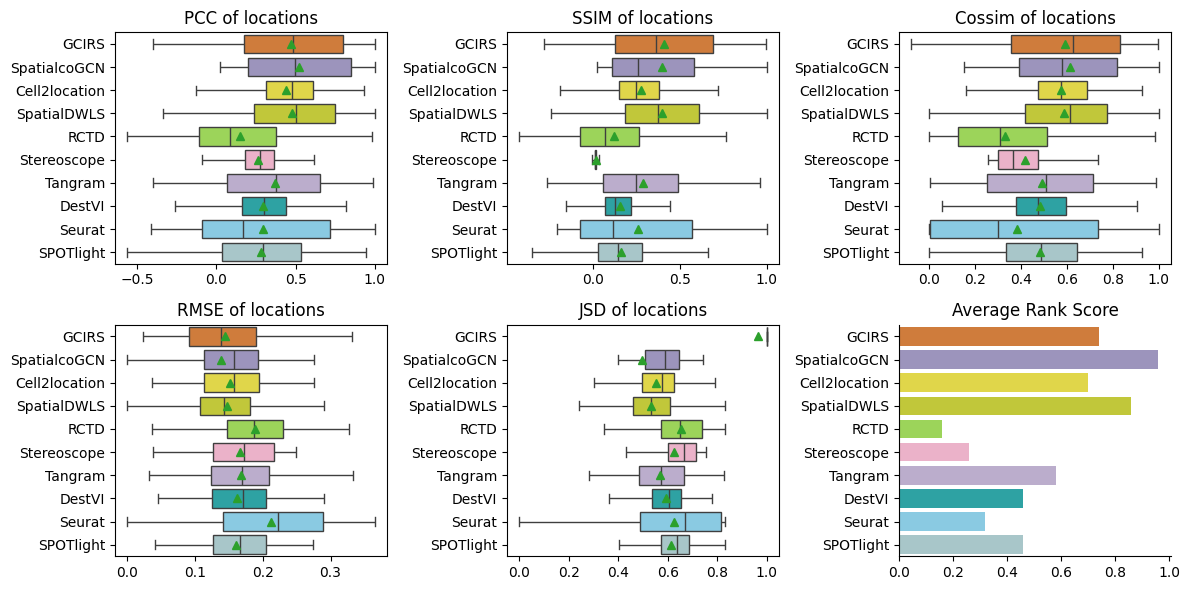

In [9]:
fig,axes = plt.subplots(ncols=3,nrows=2,figsize=(12,6))
order = ['GCIRS','SpatialcoGCN','Cell2location','SpatialDWLS','RCTD','Stereoscope','Tangram','DestVI', 'Seurat', 'SPOTlight']
colors = ['#E77923',"#988DC3","#9de846", '#F9EC31', "#BBA8D1", "#7BD1F1", "#F5A8C7",  "#A2CBCF","#D6DE23","#1AB5B7"]
sns.boxplot(data=spots_pcc,order=order,palette=colors,ax=axes[0,0],orient='h', showfliers = False,showmeans=True)
axes[0,0].set_title('PCC of locations')
sns.boxplot(data=spots_ssim,order=order,palette=colors,ax=axes[0,1],orient='h', showfliers = False,showmeans=True)
axes[0,1].set_title('SSIM of locations')
sns.boxplot(data=spots_rmse,order=order,palette=colors,ax=axes[1,0],orient='h', showfliers = False,showmeans=True)
axes[1,0].set_title('RMSE of locations')
sns.boxplot(data=spots_jsd,order=order,palette=colors,ax=axes[1,1],orient='h', showfliers = False,showmeans=True)
axes[1,1].set_title('JSD of locations')
sns.boxplot(data=spots_cossim,order=order,palette=colors,ax=axes[0,2],orient='h', showfliers = False,showmeans=True)
axes[0,2].set_title('Cossim of locations')

sns.barplot(data=ordered_result.iloc[[-1],:],order=order,palette=colors,ax=axes[1,2],orient='h',errorbar=('ci', 75))
axes[1,2].set_title('Average Rank Score')
axes[1,2].spines['top'].set_visible(False)
axes[1,2].spines['right'].set_visible(False)

#plt.delaxes(axes[1, 2])
plt.tight_layout()
# plot_file = os.path.join(DataDir+"results/metrics_plot.pdf")
# fig.savefig(plot_file,dpi=600,bbox_inches = "tight")
plt.show()